In [143]:
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/climate_watch")

df_test = pd.read_sql("SELECT * FROM GlobalLandTemperaturesByCity LIMIT 5", engine)
df_test


tables = [
    "GlobalLandTemperaturesByCity",
    "GlobalLandTemperaturesByCountry",
    "GlobalLandTemperaturesByMajorCity",
    "GlobalLandTemperaturesByState",
    "globaltemperatures"
]

with engine.connect() as conn:
    for table in tables:
        subset_table = f"{table}_subset"
        
        conn.execute(text(f"DROP TABLE IF EXISTS {subset_table}"))
        conn.execute(text(f"""
            CREATE TABLE {subset_table} AS
            SELECT *
            FROM {table}
            WHERE YEAR(dt) >= 1980;
        """))
        
        print(f"Klaar: {subset_table}")

conn.commit()

Klaar: GlobalLandTemperaturesByCity_subset
Klaar: GlobalLandTemperaturesByCountry_subset
Klaar: GlobalLandTemperaturesByMajorCity_subset
Klaar: GlobalLandTemperaturesByState_subset
Klaar: globaltemperatures_subset


In [324]:
import pandas as pd

# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCountry.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["Country"] = df["Country"].str.strip()

# 3. Make subset
df_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_subset.shape)
print(df_subset["Country"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_subset["AverageTemperature"] = (
    df_subset["AverageTemperature"]
    .fillna(df_subset.groupby("Country")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
country_avg = (
    df_subset
    .groupby("Country", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot = country_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold = country_avg.sort_values("AverageTemperature", ascending=True).head(10)

(577462, 4)
(98415, 4)
243


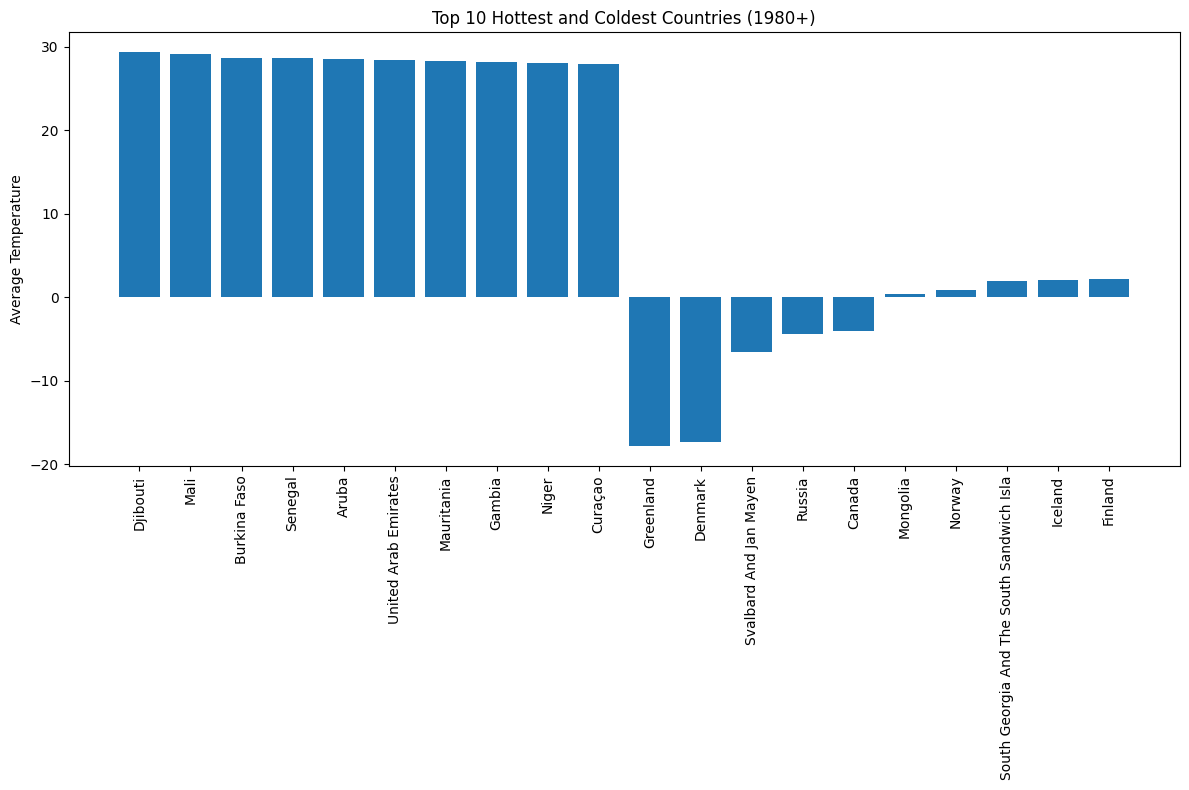

In [326]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot, top_cold])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["Country"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Countries (1980+)")
plt.tight_layout()
plt.show()

In [342]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_city_subset.shape)
print(df_city_subset["Country"].nunique())
print(df_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_city_subset["AverageTemperature"] = (
    df_city_subset["AverageTemperature"]
    .fillna(df_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_city_subset
    .groupby("City", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_cold_city)

(8599212, 7)
(1421550, 7)
159
3448
Top 10 Hottest Cities:
            City  AverageTemperature
1376      Jibuti           29.721559
3159  Umm Durman           29.652307
1516    Khartoum           29.652307
2106      Niamey           29.630797
1476     Kassala           29.486295
1975       Mopti           29.425166
2491       Rabak           29.135139
1631       Kusti           29.135139
3056    Tirupati           29.041574
2965    Tambaram           29.041574

Top 10 Coldest Cities:
                     City  AverageTemperature
2134              Norilsk          -10.802074
1635                Kyzyl           -4.956943
615                 Chita           -3.095064
3172           Ust Ilimsk           -2.775287
2080         Nefteyugansk           -2.341911
2898               Surgut           -2.341911
3153          Ulaanbaatar           -2.157579
3154             Ulan Ude           -1.963050
432                Bratsk           -1.571054
1580  Komsomolsk Na Amure           -1.378792


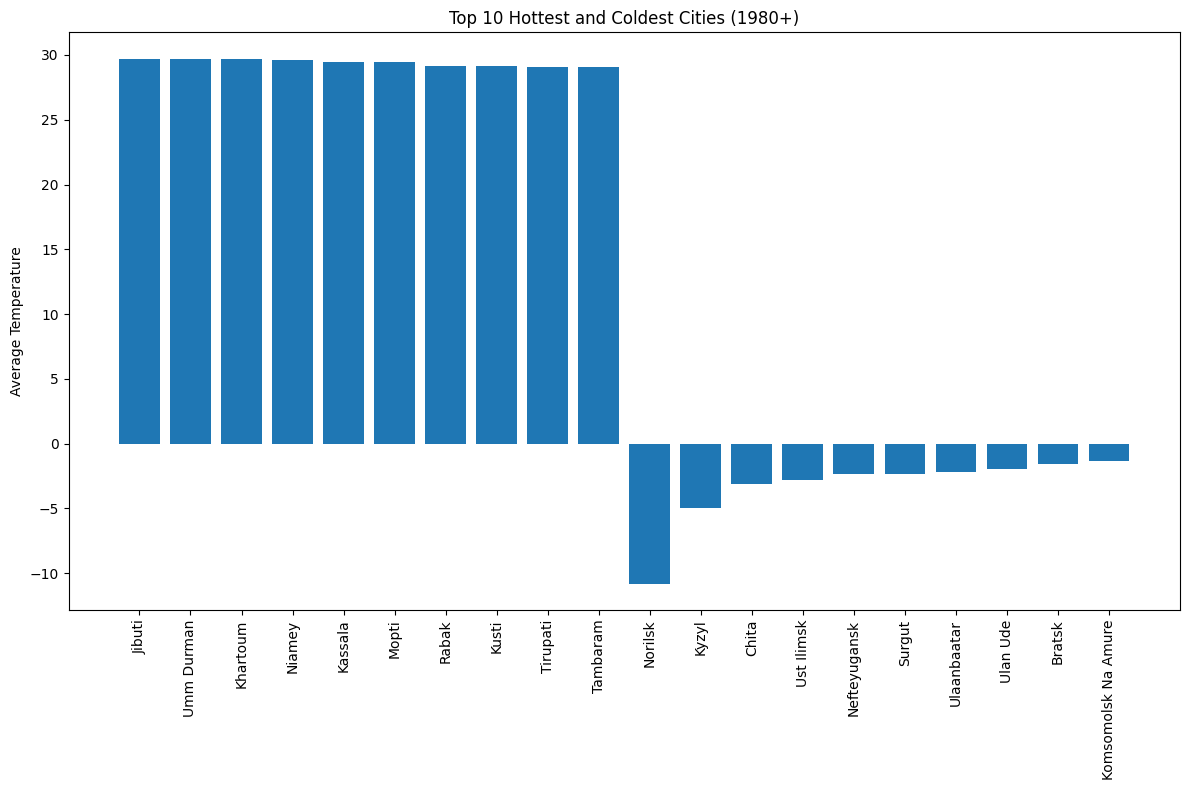

In [343]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_hot["Type"] = "Hottest"
top_cold["Type"] = "Coldest"
combined = pd.concat([top_hot_city, top_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

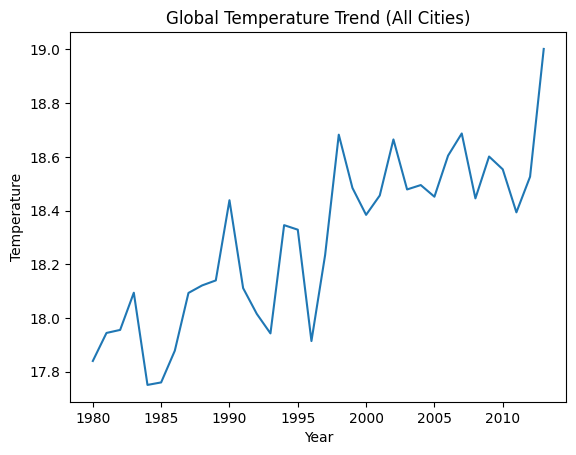

In [345]:
df_city_subset["year"] = df_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

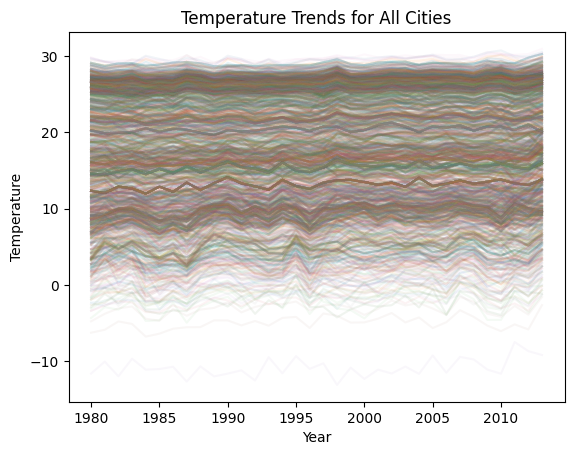

In [347]:
import matplotlib.pyplot as plt

city_yearly = ( df_city_subset.groupby(["City", "year"])["AverageTemperature"] .mean() .reset_index())

for city in city_yearly["City"].unique():
    data = city_yearly[city_yearly["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], alpha=0.05)

plt.title("Temperature Trends for All Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

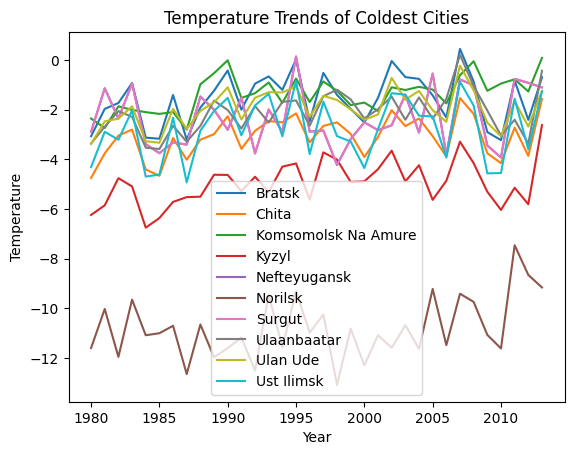

In [348]:
import matplotlib.pyplot as plt

subset = city_yearly[
    city_yearly["City"].isin(top_cold_city["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of Coldest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

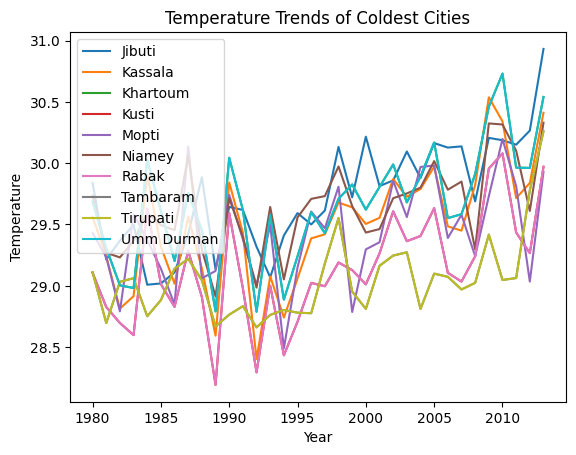

In [349]:
import matplotlib.pyplot as plt

subset = city_yearly[
    city_yearly["City"].isin(top_hot_city["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend()
plt.title("Temperature Trends of Coldest Cities")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [350]:
city_extremes = (
    df_city_subset.groupby("City")["AverageTemperature"]
    .agg(["min", "max"])
    .reset_index()
)

# verschil berekenen
city_extremes["range"] = city_extremes["max"] - city_extremes["min"]

In [356]:
top_variable = city_extremes.sort_values("range", ascending=False).head(10)


print("City with the largest temperature range:")
print(top_variable[["City", "min", "max", "range"]])

City with the largest temperature range:
                 City     min     max   range
3361           Yichun -25.568  30.589  56.157
2122   Nizhnevartovsk -34.846  21.039  55.885
2134          Norilsk -38.447  16.382  54.829
2898           Surgut -33.730  20.729  54.459
2080     Nefteyugansk -33.730  20.729  54.459
3172       Ust Ilimsk -33.250  21.082  54.332
1635            Kyzyl -35.758  17.519  53.277
390   Blagoveshchensk -28.462  23.435  51.897
1150            Heihe -28.462  23.435  51.897
2745          Seversk -29.968  21.584  51.552


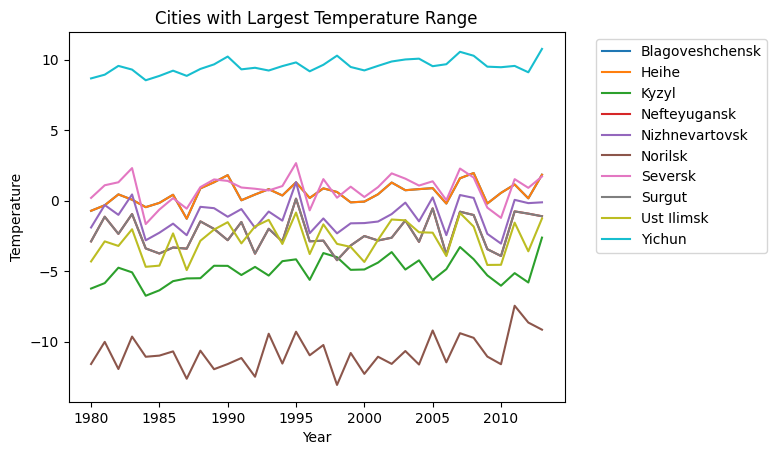

In [352]:
import matplotlib.pyplot as plt

subset = city_yearly[
    city_yearly["City"].isin(top_variable["City"])
]

for city in subset["City"].unique():
    data = subset[subset["City"] == city]
    plt.plot(data["year"], data["AverageTemperature"], label=city)

plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("Cities with Largest Temperature Range")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [357]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalLandTemperaturesByMajorCity.csv")

# 2. Clean columns
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df["AverageTemperature"] = pd.to_numeric(df["AverageTemperature"], errors="coerce")
df["AverageTemperatureUncertainty"] = pd.to_numeric(df["AverageTemperatureUncertainty"], errors="coerce")
df["Country"] = df["Country"].str.strip()
df["City"] = df["City"].str.strip()

# 3. Make subset for city data
df_major_city_subset = df[df["dt"].dt.year >= 1980].copy()

# 4. Check
print(df.shape)
print(df_major_city_subset.shape)
print(df_major_city_subset["Country"].nunique())
print(df_major_city_subset["City"].nunique())
df["dt"] = pd.to_datetime(df["dt"])


# 4. Fill missing per country (ON subset 👈)
df_major_city_subset["AverageTemperature"] = (
    df_major_city_subset["AverageTemperature"]
    .fillna(df_major_city_subset.groupby("City")["AverageTemperature"].transform("mean"))
)

# 5. Average per country
city_avg = (
    df_major_city_subset
    .groupby("City", as_index=False)["AverageTemperature"]
    .mean()
)

# 6. Top 10
top_major_hot_city = city_avg.sort_values("AverageTemperature", ascending=False).head(10)
top_major_cold_city = city_avg.sort_values("AverageTemperature", ascending=True).head(10)

print("Top 10 Hottest Cities:")
print(top_major_hot_city)              
print("\nTop 10 Coldest Cities:")
print(top_major_cold_city)

(239177, 7)
(40500, 7)
49
100
Top 10 Hottest Cities:
                City  AverageTemperature
97        Umm Durman           29.652307
57            Madras           29.041574
42            Jiddah           28.242493
35  Ho Chi Minh City           27.770054
8            Bangkok           27.765322
63         Mogadishu           27.672478
30         Fortaleza           27.638399
36         Hyderabad           27.477592
87          Surabaya           27.412795
75           Rangoon           27.332765

Top 10 Coldest Cities:
                City  AverageTemperature
34            Harbin            4.732978
79  Saint Petersburg            4.922995
65            Moscow            5.170673
64          Montreal            5.569536
19         Changchun            5.984960
81          Santiago            6.297983
96           Toronto            6.807879
48              Kiev            8.042911
85          Shenyang            8.153666
92           Taiyuan            8.801297


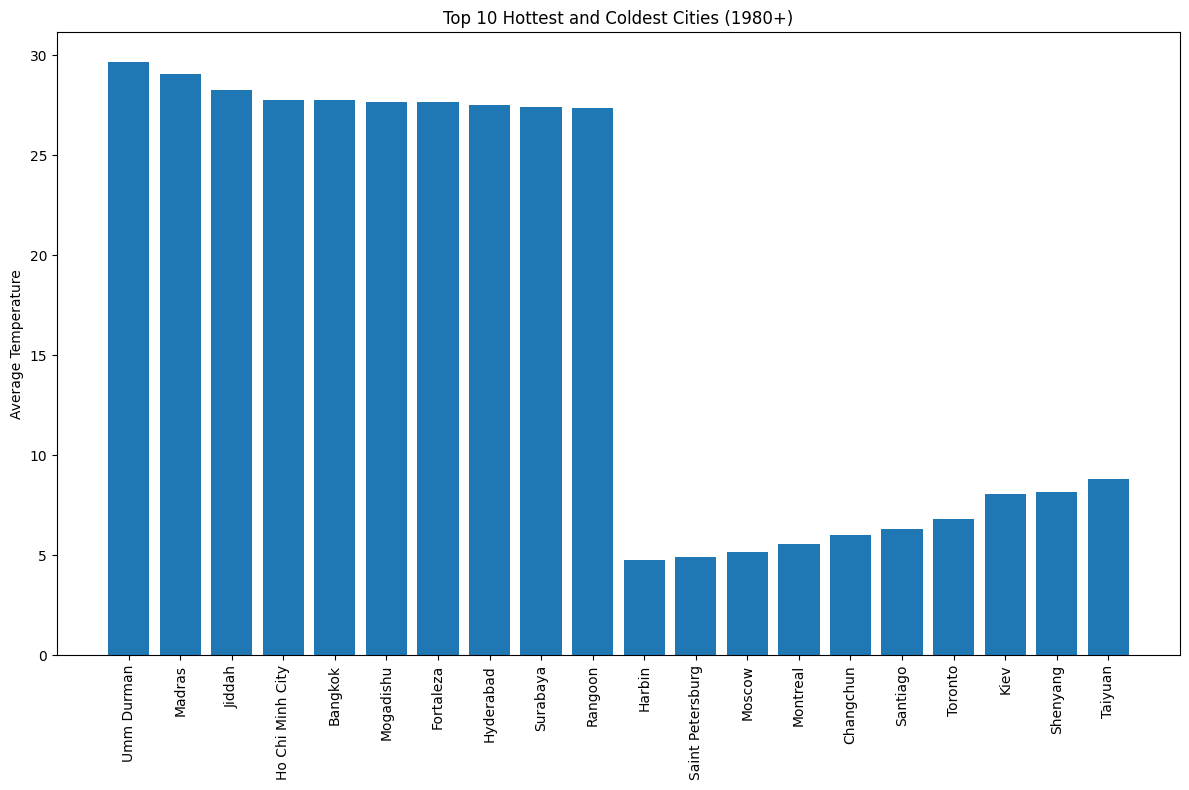

In [358]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both
top_major_hot_city["Type"] = "Hottest"
top_major_cold_city["Type"] = "Coldest"
combined = pd.concat([top_major_hot_city, top_major_cold_city])

# plot
plt.figure(figsize=(12, 8))
plt.bar(combined["City"], combined["AverageTemperature"])
plt.xticks(rotation=90)
plt.ylabel("Average Temperature")
plt.title("Top 10 Hottest and Coldest Cities (1980+)")
plt.tight_layout()
plt.show()

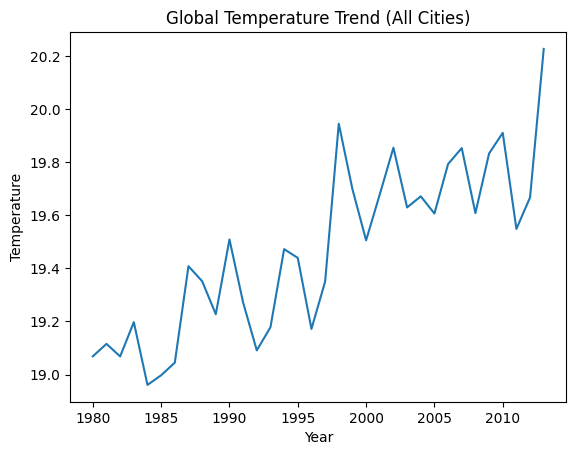

In [359]:
df_major_city_subset["year"] = df_major_city_subset["dt"].dt.year

# Gemiddelde over ALLE steden per jaar
global_trend = (
    df_major_city_subset.groupby("year")["AverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.plot(global_trend["year"], global_trend["AverageTemperature"])
plt.title("Global Temperature Trend (All Cities)")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [ ]:
# 1. Load original CSV correctly
df = pd.read_csv("/Applications/XAMPP/xamppfiles/htdocs/climate-watch/ClimateData/GlobalTemperatures.csv")

# 2. Clean columns
# 1. Date
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

# 2. Numeric columns
cols = [
    "LandAverageTemperature",
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperature",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperature",
    "LandMinTemperatureUncertainty",
    "LandAndOceanAverageTemperature"
    "LandAndOceanAverageTemperatureUncertainty"
]

for col in cols:
       df[col] = pd.to_numeric(df[col], errors="coerce")


In [364]:

df[cols].describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000


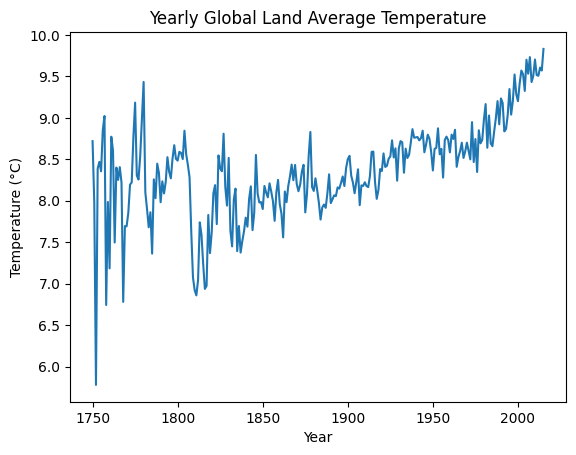

In [366]:
import matplotlib.pyplot as plt

# Create year column
df["year"] = df["dt"].dt.year

# Group by year (global average)
yearly = (
    df.groupby("year")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

# Plot
plt.figure()
plt.plot(yearly["year"], yearly["LandAverageTemperature"])

plt.title("Yearly Global Land Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.show()

In [367]:
# Make sure year exists
df["year"] = df["dt"].dt.year

# Create century (e.g. 1750 → 18th century)
df["century"] = (df["year"] // 100) + 1

In [368]:
century_avg = (
    df.groupby("century")["LandAverageTemperature"]
    .mean()
    .reset_index()
)

print(century_avg)

   century  LandAverageTemperature
0       18                8.203032
1       19                8.009105
2       20                8.637712
3       21                9.542094


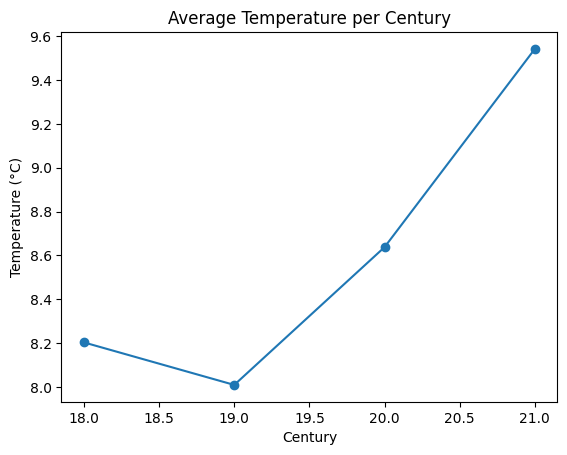

In [369]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(century_avg["century"], century_avg["LandAverageTemperature"], marker="o")

plt.title("Average Temperature per Century")
plt.xlabel("Century")
plt.ylabel("Temperature (°C)")

plt.show()

In [370]:
# Describe uncertainty columns
uncertainty_cols = [
    "LandAverageTemperatureUncertainty",
    "LandMaxTemperatureUncertainty",
    "LandMinTemperatureUncertainty"
]

print(df[uncertainty_cols].describe())

       LandAverageTemperatureUncertainty  LandMaxTemperatureUncertainty  \
count                        3180.000000                    1992.000000   
mean                            0.938468                       0.479782   
std                             1.096440                       0.583203   
min                             0.034000                       0.044000   
25%                             0.186750                       0.142000   
50%                             0.392000                       0.252000   
75%                             1.419250                       0.539000   
max                             7.880000                       4.373000   

       LandMinTemperatureUncertainty  
count                    1992.000000  
mean                        0.431849  
std                         0.445838  
min                         0.045000  
25%                         0.155000  
50%                         0.279000  
75%                         0.458250  
max         

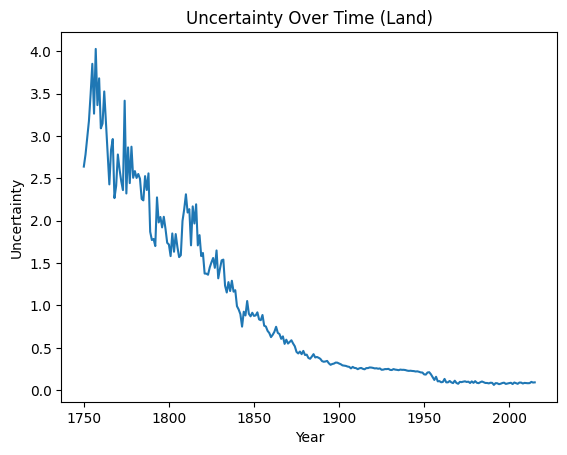

In [371]:
df["year"] = df["dt"].dt.year

uncertainty_trend = (
    df.groupby("year")["LandAverageTemperatureUncertainty"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(uncertainty_trend["year"], uncertainty_trend["LandAverageTemperatureUncertainty"])

plt.title("Uncertainty Over Time (Land)")
plt.xlabel("Year")
plt.ylabel("Uncertainty")

plt.show()

In [372]:
highest_uncertainty = uncertainty_trend.sort_values(
    "LandAverageTemperatureUncertainty", ascending=False
).head(10)

print(highest_uncertainty)

    year  LandAverageTemperatureUncertainty
7   1757                           4.026000
5   1755                           3.850333
9   1759                           3.678917
12  1762                           3.524250
4   1754                           3.494250
24  1774                           3.415167
8   1758                           3.362917
6   1756                           3.262333
3   1753                           3.176000
13  1763                           3.151583
